In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def train_df(tr_path):
    classes = []
    class_paths = []
    files = os.listdir(tr_path)
    for file in files:
        label_dir = os.path.join(tr_path, file)
        label = os.listdir(label_dir)
        for image in label:
            image_path = os.path.join(label_dir, image)
            class_paths.append(image_path)
            classes.append(file)
    image_classes = pd.Series(classes, name='Class')
    image_paths = pd.Series(class_paths, name='Class Path')
    tr_df = pd.concat([image_paths, image_classes], axis=1)
    return tr_df

In [ ]:
tr_df = train_df('/content/drive/MyDrive/OS Collected Data')
tr_df

,Class Path,Class
0,/content/drive/MyDrive/OS Collected Data/Norma...,Normal
1,/content/drive/MyDrive/OS Collected Data/Norma...,Normal
2,/content/drive/MyDrive/OS Collected Data/Norma...,Normal
3,/content/drive/MyDrive/OS Collected Data/Norma...,Normal
4,/content/drive/MyDrive/OS Collected Data/Norma...,Normal
...,...,...
1945,/content/drive/MyDrive/OS Collected Data/Osteo...,Osteopenia
1946,/content/drive/MyDrive/OS Collected Data/Osteo...,Osteopenia
1947,/content/drive/MyDrive/OS Collected Data/Osteo...,Osteopenia
1948,/content/drive/MyDrive/OS Collected Data/Osteo...,Osteopenia


In [ ]:
train_df, dummies_df = train_test_split(tr_df, test_size=0.2, random_state=42)
valid_df, test_df = train_test_split(dummies_df, test_size=0.5, random_state=42)

In [ ]:
# Make sure the new size is set right here
batch_size = 2 # Reminder: Lower this if you get an OOM (Out of Memory) error!
img_size = (480, 480)

tr_gen = ImageDataGenerator(brightness_range=(.8,1.2))
gen = ImageDataGenerator()

# Re-create the training generator with the 480x480 target_size
tr_gen = tr_gen.flow_from_dataframe(train_df, x_col='Class Path',
                                 y_col='Class', batch_size=batch_size,
                                 target_size=img_size)

# Re-create the validation generator with the 480x480 target_size
valid_gen = gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                    y_col='Class', batch_size=batch_size,
                                    target_size=img_size)

# Re-create the test generator with the 480x480 target_size
ts_gen = gen.flow_from_dataframe(test_df, x_col='Class Path',
                                y_col='Class', batch_size=batch_size,
                                 target_size=img_size, shuffle=False)

Found 1560 validated image filenames belonging to 3 classes.
Found 195 validated image filenames belonging to 3 classes.
Found 195 validated image filenames belonging to 3 classes.


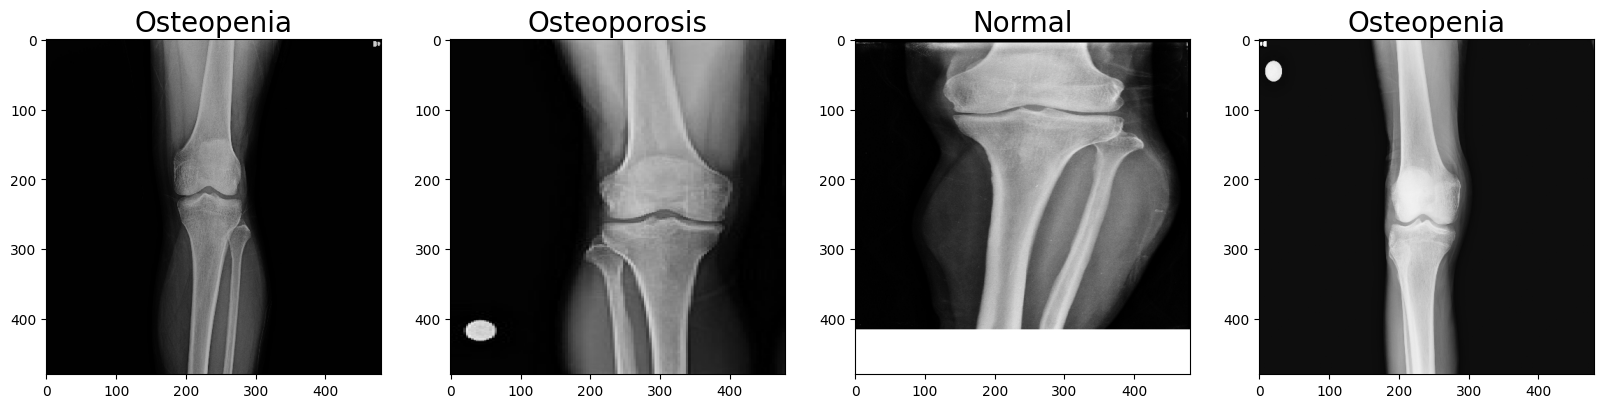

In [ ]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(tr_gen)

plt.figure(figsize= (20, 20))

for i in range(len(images)): # Changed from range(16) to range(len(images))
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color='k', fontsize=20)
plt.show()

In [ ]:
num_classes = len(classes)
num_classes

3

In [ ]:
# Change this earlier in your code
img_size = (480, 480)

# And change this right before your base_model
img_shape = (480, 480, 3)
base_model = tf.keras.applications.EfficientNetV2L(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

model = Sequential([
    base_model,
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(num_classes, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy'])
model.build((None, 480, 480, 3))
model.summary()

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 1280)           │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,911,203 (449.80 MB)

 Trainable params: 117,398,627 (447.84 MB)

 Non-trainable params: 512,576 (1.96 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Model Checkpoint: Saves the BEST model automatically based on validation accuracy
checkpoint = ModelCheckpoint(
    filepath="best_knee_Model_EfficientNetV2L.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# 2. Early Stopping: Stops training if the model stops improving, preventing overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3, # Will wait 3 epochs without improvement before stopping
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce LR on Plateau: Lowers the learning rate if validation loss gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,   # Cuts learning rate in half
    patience=2,   # If loss doesn't improve for 2 epochs
    min_lr=0.00001,
    verbose=1
)

# Bundle them up
my_callbacks = [checkpoint, early_stop, reduce_lr]

# The Upgraded Training Loop
history = model.fit(
    tr_gen,
    epochs=15, # You can safely increase this now because EarlyStopping will catch it!
    validation_data=valid_gen,
    callbacks=my_callbacks,
    shuffle=False # Note: shuffle is ignored when using generators anyway
)

Epoch 1/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5571 - loss: 0.7590
Epoch 1: val_accuracy improved from None to 0.75897, saving model to best_knee_Model_EfficientNetV2L.h5



Epoch 1: finished saving model to best_knee_Model_EfficientNetV2L.h5
390/390 ━━━━━━━━━━━━━━━━━━━━ 1057s 2s/step - accuracy: 0.6173 - loss: 0.5548 - val_accuracy: 0.7590 - val_loss: 0.3541 - learning_rate: 0.0010
Epoch 2/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.7221 - loss: 0.4095
Epoch 2: val_accuracy improved from 0.75897 to 0.81026, saving model to best_knee_Model_EfficientNetV2L.h5



Epoch 2: finished saving model to best_knee_Model_EfficientNetV2L.h5
390/390 ━━━━━━━━━━━━━━━━━━━━ 334s 854ms/step - accuracy: 0.7321 - loss: 0.3957 - val_accuracy: 0.8103 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 3/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.7847 - loss: 0.3495
Epoch 3: val_accuracy did not improve from 0.81026
390/390 ━━━━━━━━━━━━━━━━━━━━ 291s 747ms/step - accuracy: 0.7647 - loss: 0.3720 - val_accuracy: 0.7692 - val_loss: 0.3292 - learning_rate: 0.0010
Epoch 4/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.7611 - loss: 0.3525
Epoch 4: val_accuracy did not improve from 0.81026

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
390/390 ━━━━━━━━━━━━━━━━━━━━ 293s 750ms/step - accuracy: 0.7673 - loss: 0.3432 - val_accuracy: 0.7744 - val_loss: 0.3444 - learning_rate: 0.0010
Epoch 5/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.8283 - loss: 0.2676
Epoch 5: val_accuracy improved from 0.81026 to 0.887


Epoch 5: finished saving model to best_knee_Model_EfficientNetV2L.h5
390/390 ━━━━━━━━━━━━━━━━━━━━ 336s 862ms/step - accuracy: 0.8417 - loss: 0.2473 - val_accuracy: 0.8872 - val_loss: 0.1807 - learning_rate: 5.0000e-04
Epoch 6/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.8929 - loss: 0.1767
Epoch 6: val_accuracy did not improve from 0.88718
390/390 ━━━━━━━━━━━━━━━━━━━━ 293s 750ms/step - accuracy: 0.8974 - loss: 0.1814 - val_accuracy: 0.8615 - val_loss: 0.2274 - learning_rate: 5.0000e-04
Epoch 7/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9046 - loss: 0.1616
Epoch 7: val_accuracy improved from 0.88718 to 0.89231, saving model to best_knee_Model_EfficientNetV2L.h5



Epoch 7: finished saving model to best_knee_Model_EfficientNetV2L.h5

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
390/390 ━━━━━━━━━━━━━━━━━━━━ 331s 850ms/step - accuracy: 0.9071 - loss: 0.1644 - val_accuracy: 0.8923 - val_loss: 0.1862 - learning_rate: 5.0000e-04
Epoch 8/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.9307 - loss: 0.1064
Epoch 8: val_accuracy did not improve from 0.89231
390/390 ━━━━━━━━━━━━━━━━━━━━ 294s 752ms/step - accuracy: 0.9276 - loss: 0.1175 - val_accuracy: 0.8923 - val_loss: 0.1538 - learning_rate: 2.5000e-04
Epoch 9/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.9414 - loss: 0.0931
Epoch 9: val_accuracy did not improve from 0.89231
390/390 ━━━━━━━━━━━━━━━━━━━━ 292s 748ms/step - accuracy: 0.9314 - loss: 0.1003 - val_accuracy: 0.8821 - val_loss: 0.1796 - learning_rate: 2.5000e-04
Epoch 10/15
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.9490 - loss: 0.0855
Epoch 10: val_accuracy did not improve 

In [ ]:
model.evaluate(ts_gen, verbose=1)

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.9231 - loss: 0.1255


[0.12551699578762054, 0.9230769276618958]

In [ ]:
model.save("knee_Model.h5")

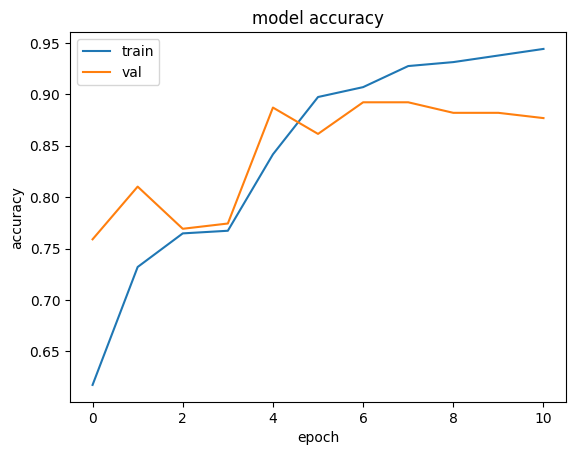

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

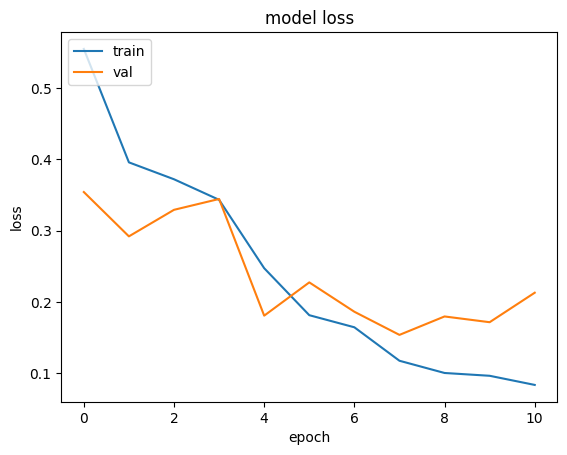

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
pred = model.predict(ts_gen)
pred = np.argmax(pred, axis=1)

labels = (tr_gen.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_df['Class']
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

              precision    recall  f1-score   support

      Normal       0.94      0.93      0.94        89
  Osteopenia       0.91      0.89      0.90        36
Osteoporosis       0.90      0.93      0.92        70

    accuracy                           0.92       195
   macro avg       0.92      0.92      0.92       195
weighted avg       0.92      0.92      0.92       195

Accuracy of the Model: 92.3%


In [ ]:
classes=list(tr_gen.class_indices.keys())
print (classes)

['Normal', 'Osteopenia', 'Osteoporosis']


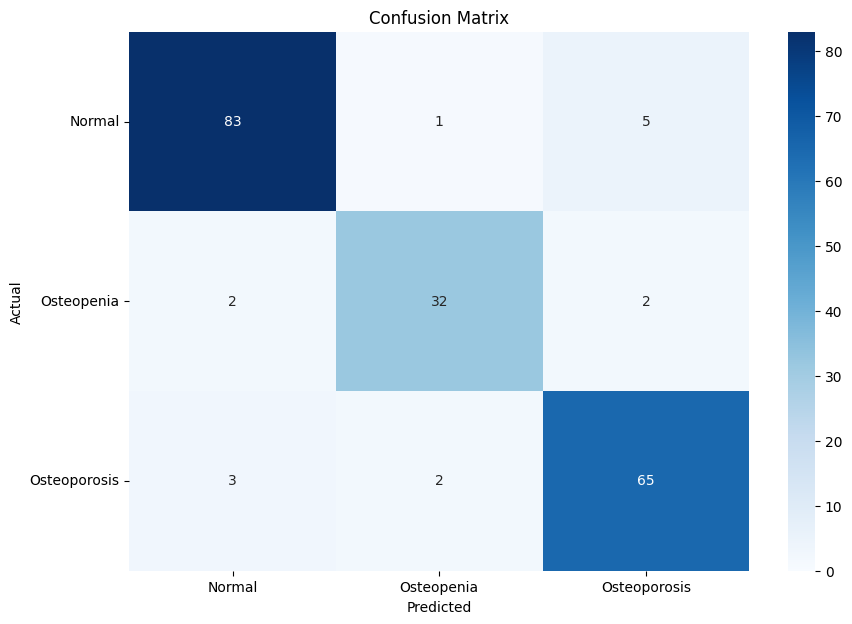

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = test_df['Class'].values
cm = confusion_matrix(y_true, pred2)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

num_classes = len(classes)

plt.xticks(ticks=[i + 0.5 for i in range(num_classes)], labels=classes, rotation=0)
plt.yticks(ticks=[i + 0.5 for i in range(num_classes)], labels=classes, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()